### Problem Definition
- **What problem are we solving?** Predicting individual medical insurance costs based on personal attributes.
- **What type of ML problem is this?** Supervised Regression with an emphasis on feature weights.

---

### Dataset
- **What information does this dataset contain?** Age, BMI, smoking status, and dependents.
- **What is the target?** Medical Charges (Continuous variable).
- **What assumptions can we make before analysis?** Smoking and high BMI will exponentially increase costs.

In [238]:
import pandas as pd

df = pd.read_csv('./data/insurance.csv')

### Exploratory Data Analysis
- **What should we learn from EDA?** The separation of costs between smokers and non-smokers.
- **Which features immediately look informative?** The `smoker` column will likely be the dominant factor.

In [239]:
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df[df.duplicated(keep=False)])
print(df.isna().sum())

df.drop_duplicates(inplace=True)

df.rename(columns={'children': 'num_of_children'}, inplace=True)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges

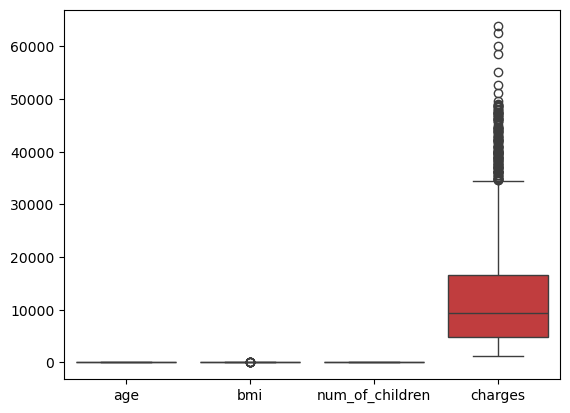

Lower bound: -13120.716174999998 
 Upper bound: 34524.777625
      age     sex     bmi  num_of_children smoker     region      charges
14     27    male  42.130                0    yes  southeast  39611.75770
19     30    male  35.300                0    yes  southwest  36837.46700
23     34  female  31.920                1    yes  northeast  37701.87680
29     31    male  36.300                2    yes  southwest  38711.00000
30     22    male  35.600                0    yes  southwest  35585.57600
...   ...     ...     ...              ...    ...        ...          ...
1300   45    male  30.360                0    yes  southeast  62592.87309
1301   62    male  30.875                3    yes  northwest  46718.16325
1303   43    male  27.800                0    yes  southwest  37829.72420
1313   19  female  34.700                2    yes  southwest  36397.57600
1323   42  female  40.370                2    yes  southeast  43896.37630

[139 rows x 7 columns]


In [240]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df.select_dtypes(include='number'))
plt.show()

q1 = df['charges'].quantile(0.25)
q3 = df['charges'].quantile(0.75)

IQR = q3 - q1
Lower_bound = q1 - 1.5 * IQR
Upper_bound = q3 + 1.5 * IQR

print(f'Lower bound: {Lower_bound} \n Upper bound: {Upper_bound}')

outliers_df = df[(df['charges'] < Lower_bound) | (df['charges'] > Upper_bound)]

print(outliers_df)


### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

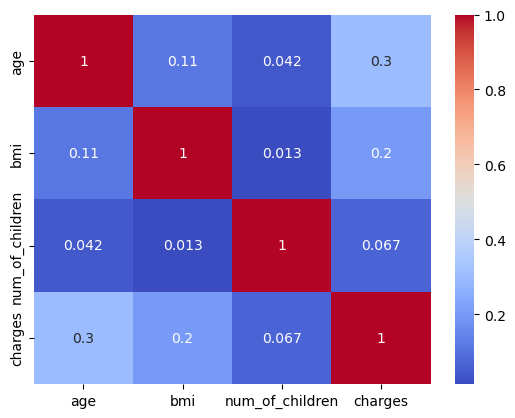

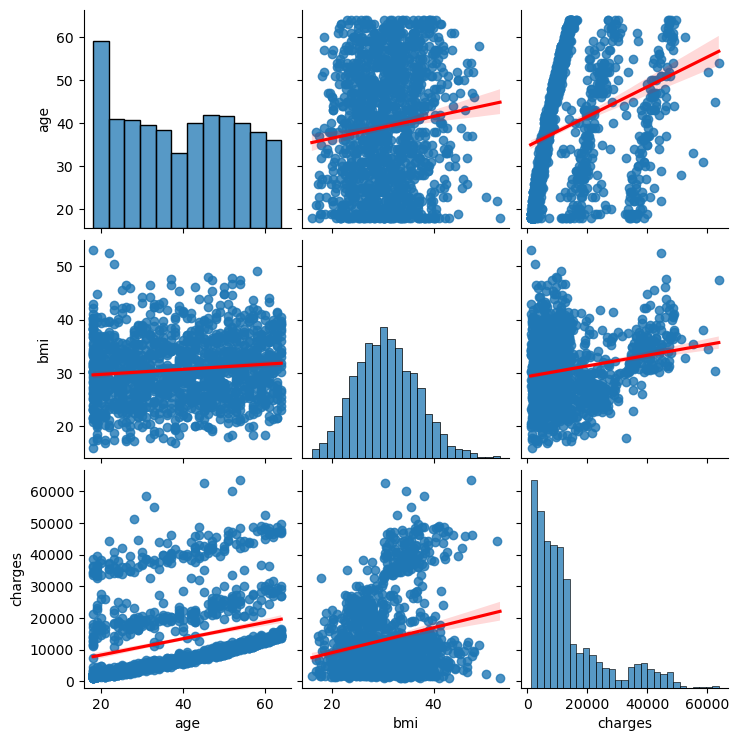

In [241]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()


sns.pairplot(
    df[['age','bmi','smoker','charges']], 
    kind='reg', 
    plot_kws={'line_kws':{'color':'red'}}
)
plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

             age        bmi  num_of_children       charges
count  10.000000  10.000000        10.000000     10.000000
mean   56.200000  31.542500         1.800000  32662.649775
std     6.214678   5.114248         1.135292   2709.908603
min    44.000000  24.700000         0.000000  30063.580550
25%    52.750000  27.248750         1.000000  30266.157405
50%    57.000000  31.532500         2.000000  31864.331940
75%    60.750000  36.345000         2.000000  34738.093900
max    64.000000  37.715000         4.000000  36910.608030


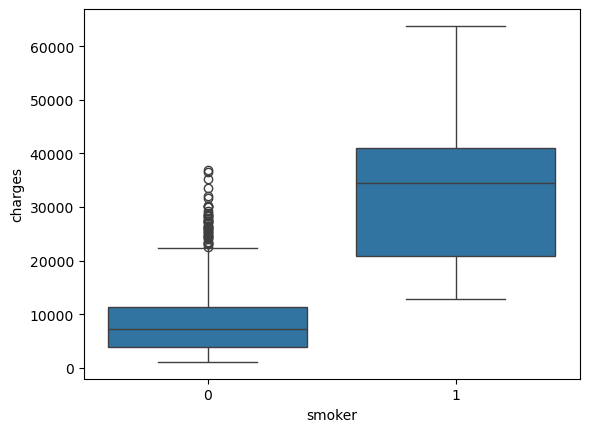

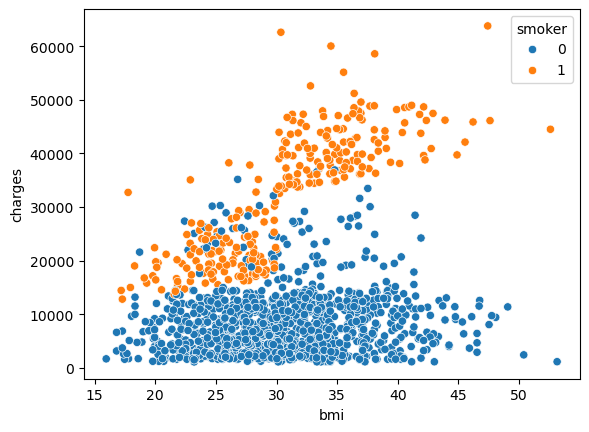

In [242]:
high_charges_non_smoker = df[(df['smoker'] == 'no') & (df['charges'] > 30000)]

print(high_charges_non_smoker.describe()) # hence worth it

df['smoker'] = df['smoker'].map({
    'no': 0,
    'yes': 1
})

df['smoker_bmi'] = df['smoker'] * df['bmi']

df['age_range'] = pd.cut(
    df['age'], 
    bins=[0, 30, 45, 60, 120], 
    labels=['young_adult', 'adult', 'middle_age', 'senior'],
    include_lowest=True)

df['bmi_range'] = pd.cut(
    df['bmi'], 
    bins=[0, 18.5, 25, 30, 100], 
    labels=['under_weight', 'normal', 'overweight', 'obese'])

sns.boxplot(
    x="smoker",
    y="charges",
    data=df
)
plt.show()

sns.scatterplot(x=df['bmi'], y=df['charges'], hue='smoker', data=df)
plt.show()

### Visualization Analysis: Scatter/Pair Plot
- **Marking Values:** Look for distinct clusters, straight lines, or chaotic clouds of points.
- **Correct Interpretation:** A clear diagonal trend indicates a linear relationship. Distinct, separated blobs indicate the data is highly clusterable or easily classified.
- **How to Interpret:** Each dot represents a single row of data plotted across two feature dimensions.
- **Common Mistakes:** Over-interpreting a 2D scatter plot when the model actually operates in high-dimensional space (PCA should be used to crush dimensions first).

In [243]:
import numpy as np

X = df.drop(columns='charges')
y = df['charges']

X.select_dtypes(include='number').skew()

age                0.054781
bmi                0.283914
num_of_children    0.937421
smoker             1.463601
smoker_bmi         1.652517
dtype: float64

### Data Preprocessing
- **Encoding:** Categorical flags (like `smoker_yes`) must be binary encoded (0 or 1) so the regression math can calculate a multiplier (weight) for them.

In [244]:
from sklearn.model_selection import train_test_split

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80, random_state=42)

# Project categorical variables into orthogonal binary vectors to prevent the model from falsely assuming ordinal relationships.
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
# Project categorical variables into orthogonal binary vectors to prevent the model from falsely assuming ordinal relationships.
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

In [245]:
from sklearn.preprocessing import StandardScaler

# Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

### Model Selection
- **Why choose this algorithm?** Multiple Linear Regression allows us to inspect the exact dollar amount each feature adds to the bill.
- **What are its strengths?** Perfect interpretability. We can tell a patient exactly *why* their premium increased.

In [246]:
from sklearn.linear_model import LinearRegression

# Minimize the residual sum of squares between observed targets and the responses predicted by the linear approximation.
model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(model.coef_)
print(model.intercept_)

[ 3978.76251472 -1305.82945471   810.63896199 -8620.5587847
 18272.87318995  -313.06865737  -205.10636012  -315.78459577
  -398.16709194  -778.49680733  -536.72615115  -149.08778521
   486.5922156    528.54835283  2246.69803331]
13030.203369289053


### Evaluation
- **Why these metrics?** R² and MAE. MAE tells us exactly how many dollars off our prediction is on average.

In [247]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# Calculate the average absolute prediction error. Highly interpretable metric for business stakeholders.
linear_mae = mean_absolute_error(y_test, y_pred)
# Heavily penalize massive prediction errors by squaring the residuals before averaging.
linear_mse = mean_squared_error(y_test, y_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, y_pred)

print(f"MAE: {linear_mae:.4f}")
print(f"MSE: {linear_mse:.4f}")
print(f"RMSE: {linear_rmse:.4f}")
print(f"R2: {linear_r2:.4f}")

MAE: 2846.8069
MSE: 21015810.0059
RMSE: 4584.3004
R2: 0.8856


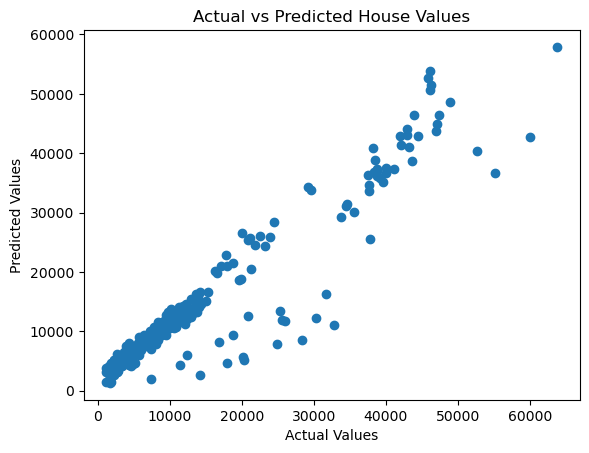

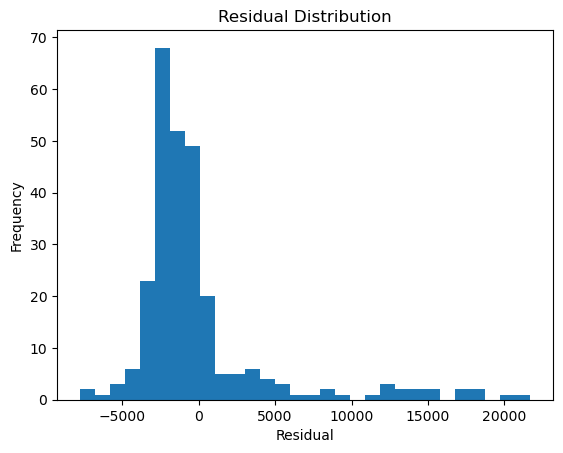

In [248]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Values")

plt.show()

residuals = y_test - y_pred

plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.show()

### Visualization Analysis: Scatter/Pair Plot
- **Marking Values:** Look for distinct clusters, straight lines, or chaotic clouds of points.
- **Correct Interpretation:** A clear diagonal trend indicates a linear relationship. Distinct, separated blobs indicate the data is highly clusterable or easily classified.
- **How to Interpret:** Each dot represents a single row of data plotted across two feature dimensions.
- **Common Mistakes:** Over-interpreting a 2D scatter plot when the model actually operates in high-dimensional space (PCA should be used to crush dimensions first).

In [249]:
from sklearn.model_selection import cross_val_score

# Project categorical variables into orthogonal binary vectors to prevent the model from falsely assuming ordinal relationships.
X_encoded = pd.get_dummies(X, drop_first=True)
# Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
linear_cv = cross_val_score(model, X_encoded, y, cv=5)

print(f"CV R² Scores: {linear_cv}")
print(f"Mean CV R²: {linear_cv.mean():.4f}")
print(f"Std CV R²: {linear_cv.std():.4f}")

CV R² Scores: [0.86488607 0.79764816 0.88294771 0.82834923 0.84051814]
Mean CV R²: 0.8429
Std CV R²: 0.0295


In [250]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

# Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
ridge_cv = cross_val_score(ridge, X_train_scaled, y_train, cv=5, scoring='r2')

print(f'labmda: {ridge.alpha_}')
print(f'ridge_cv: {ridge_cv.mean():.4f}')

# Calculate the average absolute prediction error. Highly interpretable metric for business stakeholders.
ridge_mae = mean_absolute_error(y_test, ridge_pred)
# Heavily penalize massive prediction errors by squaring the residuals before averaging.
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print(f"MAE: {ridge_mae:.4f}")
print(f"MSE: {ridge_mse:.4f}")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"R2: {ridge_r2:.4f}")

labmda: 0.1
ridge_cv: 0.8305
MAE: 2846.5301
MSE: 21007829.6872
RMSE: 4583.4299
R2: 0.8857


In [251]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5, max_iter=10000)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

# Evaluate model robustness by partitioning data into k folds, preventing the model from just getting "lucky" on a single split.
lasso_cv = cross_val_score(lasso, X_train_scaled, y_train, cv=5, scoring='r2')

print(f'labmda: {lasso.alpha_}')
print(f'lasso_cv: {lasso_cv.mean():.4f}')

# Calculate the average absolute prediction error. Highly interpretable metric for business stakeholders.
lasso_mae = mean_absolute_error(y_test, lasso_pred)
# Heavily penalize massive prediction errors by squaring the residuals before averaging.
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print(f"MAE: {lasso_mae:.4f}")
print(f"MSE: {lasso_mse:.4f}")
print(f"RMSE: {lasso_rmse:.4f}")
print(f"R2: {lasso_r2:.4f}")

labmda: 1.0
lasso_cv: 0.8303
MAE: 2846.7494
MSE: 20998656.1575
RMSE: 4582.4291
R2: 0.8857


In [254]:
metrics_df = pd.DataFrame({
    'mae': [linear_mae, ridge_mae, lasso_mae],
    'mse': [linear_mse, ridge_mse, lasso_mse],
    'rmse': [linear_rmse, ridge_rmse, lasso_rmse],
    'r2': [linear_r2, ridge_r2, lasso_r2],
    'cv_mean': [linear_cv.mean(), ridge_cv.mean(), lasso_cv.mean()]
}, index=['Linear', 'Ridge', 'Lasso'])

print(metrics_df.to_markdown())


|        |     mae |         mse |    rmse |       r2 |   cv_mean |
|:-------|--------:|------------:|--------:|---------:|----------:|
| Linear | 2846.81 | 2.10158e+07 | 4584.3  | 0.885632 |  0.84287  |
| Ridge  | 2846.53 | 2.10078e+07 | 4583.43 | 0.885675 |  0.830549 |
| Lasso  | 2846.75 | 2.09987e+07 | 4582.43 | 0.885725 |  0.830314 |


In [253]:
feature_importance_linear = pd.Series(
    model.coef_,
    index=X_train_encoded.columns
).sort_values(ascending=False)

feature_importance_ridge = pd.Series(
    ridge.coef_,
    index=X_train_encoded.columns
).sort_values(ascending=False)

feature_importance_lasso = pd.Series(
    lasso.coef_,
    index=X_train_encoded.columns
).sort_values(ascending=False)


feature_importance_df = pd.DataFrame({
    'Linear': feature_importance_linear,
    'Ridge': feature_importance_ridge,
    'Lasso': feature_importance_lasso
})

print(feature_importance_df.to_markdown())



|                      |    Linear |     Ridge |     Lasso |
|:---------------------|----------:|----------:|----------:|
| smoker_bmi           | 18272.9   | 18208.2   | 18221     |
| age                  |  3978.76  |  3973.63  |  3943.06  |
| bmi_range_obese      |  2246.7   |  2241.42  |  2180.48  |
| num_of_children      |   810.639 |   810.422 |   808.876 |
| bmi_range_overweight |   528.548 |   524.773 |   475.185 |
| bmi_range_normal     |   486.592 |   483.61  |   446.388 |
| age_range_senior     |  -149.088 |  -146.026 |  -122.071 |
| region_northwest     |  -205.106 |  -204.855 |  -201.17  |
| sex_male             |  -313.069 |  -312.173 |  -311.439 |
| region_southeast     |  -315.785 |  -315.703 |  -312.848 |
| region_southwest     |  -398.167 |  -397.693 |  -394.368 |
| age_range_middle_age |  -536.726 |  -531.969 |  -498.691 |
| age_range_adult      |  -778.497 |  -776.541 |  -758.574 |
| bmi                  | -1305.83  | -1297.91  | -1287.95  |
| smoker               |

### Conclusion
- **Biggest takeaway:** Lifestyle choices (smoking) mathematically dominate the insurance premium calculation.
- **Main limitation:** Linear models assume adding 1 BMI point costs the same for an 18-year-old as a 60-year-old.